# Skewness

## Definition

**Skewness** measures how asymmetric (uneven) a distribution is.

It tells us whether the data is stretched more to the left or right side.

---

## Why It Matters

Skewness helps us:

- Understand the shape of data
- Detect outliers
- Choose appropriate transformations
- Prepare data for machine learning models

---

## Types of Skewness

### 1. Symmetric Distribution (Skewness = 0)

- Left and right sides are balanced.
- Mean = Median = Mode

```
        /\
       /  \
      /    \
_____/______\_____
```

Example:
- Heights of adults (approximately)

---

### 2. Positive Skew (Right Skew)

- Tail extends to the right.
- Large values pull the mean upward.

```
      /\
     /  \
    /    \______
___/             \____
```

Relationship:

```text
Mean > Median > Mode
```

Examples:
- Income
- House prices
- Social media followers

---

### 3. Negative Skew (Left Skew)

- Tail extends to the left.
- Small values pull the mean downward.

```
          /\
         /  \
________/    \__
```

Relationship:

```text
Mean < Median < Mode
```

Examples:
- Easy exam scores
- Retirement age

---

## Interpreting Skewness Values

| Skewness | Interpretation |
|-----------|---------------|
| 0 | Perfectly Symmetric |
| -0.5 to 0.5 | Approximately Symmetric |
| 0.5 to 1 | Moderately Positive Skew |
| > 1 | Highly Positive Skew |
| -0.5 to -1 | Moderately Negative Skew |
| < -1 | Highly Negative Skew |

---

## Finding Skewness in Python

Example:

```python
df['income'].skew()
```

Output:

```text
2.3
```

Interpretation:

```text
Highly Positively Skewed
```

---

## Handling Skewed Data

Common techniques:

- Log Transformation
- Square Root Transformation
- Box-Cox Transformation
- Removing Outliers

Example:

```python
import numpy as np

df['income_log'] = np.log1p(df['income'])
```

---

## In Machine Learning

Check skewness during:

- EDA (Exploratory Data Analysis)
- Feature Engineering
- Data Preprocessing

Highly skewed features may affect:

- Linear Regression
- Logistic Regression
- K-Means Clustering

Tree-based models (Random Forest, XGBoost) are usually less affected.

---

## One-Line Revision

> Skewness tells us the direction and degree of asymmetry in a dataset.

---

## Memory Trick

### "Tail tells the Tale"

- Tail Right → Positive Skew
- Tail Left → Negative Skew

Remember:

> **Follow the tail to identify the skew.**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import yeojohnson

In [3]:
# Positive Skewness

skewed_data = np.random.exponential(scale=2, size=100000)

In [36]:
import pandas as pd

pd.Series(skewed_data).skew()

np.float64(1.9859144737749266)

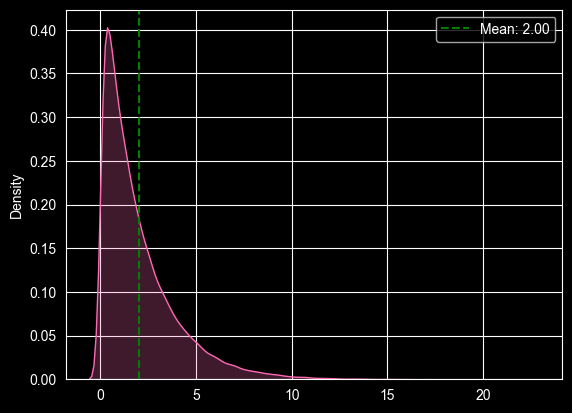

In [11]:
sns.kdeplot(skewed_data, color="hotpink", fill=True)

mean_value = skewed_data.mean()

plt.axvline(mean_value, color="green", linestyle="dashed", label=f"Mean: {mean_value:.2f}")

plt.legend()
plt.show()

## Techniques to Handle Positive Skewness

In [20]:
# Log Transformation
log_skewed_data = np.log(skewed_data)

# Squared Root Transformation
squared_skewed_data = np.sqrt(skewed_data)

from sklearn.preprocessing import PowerTransformer

# Box-Cox Transformation
pt = PowerTransformer(method='box-cox')
box_cox_skewed_data = pt.fit_transform(skewed_data.reshape(-1, 1))

# Yeo-Johnson Transformation
pt = PowerTransformer(method='yeo-johnson')
yeo_johnson_skewed_data = pt.fit_transform(skewed_data.reshape(-1, 1))

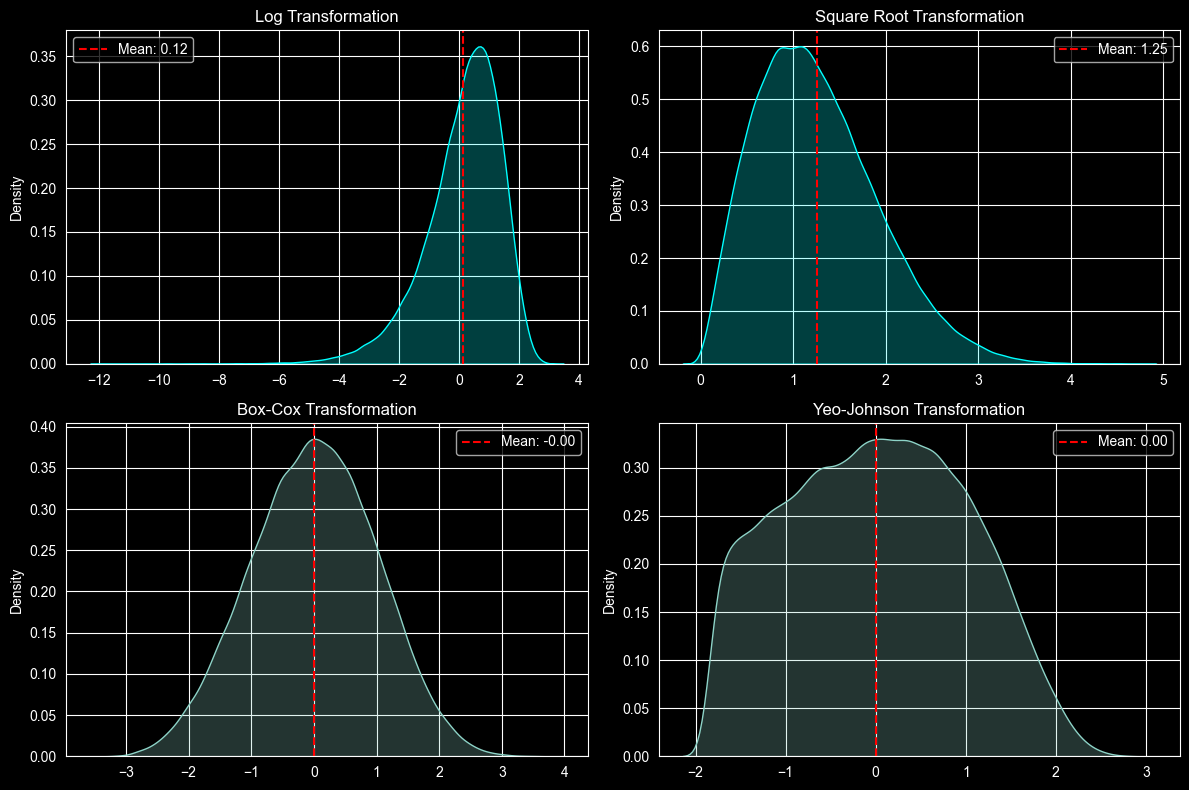

In [28]:
fig, ax = plt.subplots(2,2, figsize=(12,8))

ax = ax.flatten()

data_list = [log_skewed_data, squared_skewed_data, box_cox_skewed_data, yeo_johnson_skewed_data]

titles = ["Log Transformation", "Square Root Transformation", "Box-Cox Transformation", "Yeo-Johnson Transformation"]

for index, data in enumerate(data_list):

    sns.kdeplot(data, color="cyan", fill=True, ax=ax[index])

    mean_value = data.mean()

    ax[index].axvline(mean_value, color="red", linestyle="dashed", label=f"Mean: {mean_value:.2f}")

    ax[index].set_title(titles[index])

    ax[index].legend()

plt.tight_layout()
plt.show()

## Negative Skewness

In [51]:
import numpy as np

neg_skewed_data = 100 - np.random.exponential(scale=2, size=100000)

In [52]:
import pandas as pd

pd.Series(neg_skewed_data).skew()

np.float64(-2.0077496985980328)

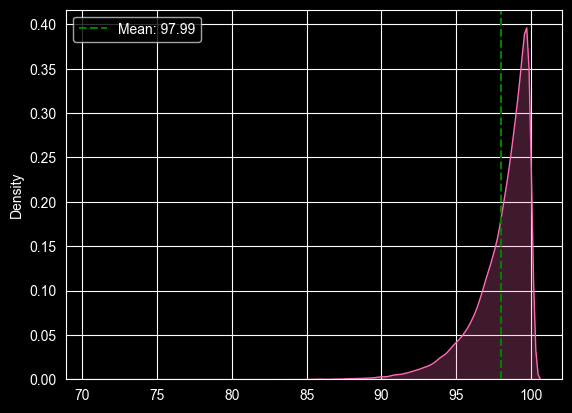

In [53]:
sns.kdeplot(neg_skewed_data, color="hotpink", fill=True)

mean_value = neg_skewed_data.mean()

plt.axvline(mean_value, color="green", linestyle="dashed", label=f"Mean: {mean_value:.2f}")

plt.legend()
plt.show()

In [58]:
# Squared Transformation
squared_skewed_data = neg_skewed_data ** 2

# Cubed Transformation
cubed_skewed_data = neg_skewed_data ** 3

from sklearn.preprocessing import PowerTransformer

# Cannot handles negative values

# Box-Cox Transformation
pt = PowerTransformer(method='box-cox')
box_cox_skewed_data = pt.fit_transform(neg_skewed_data.reshape(-1, 1))

# Yeo-Johnson Transformation
pt = PowerTransformer(method='yeo-johnson')
yeo_johnson_skewed_data = pt.fit_transform(neg_skewed_data.reshape(-1, 1))

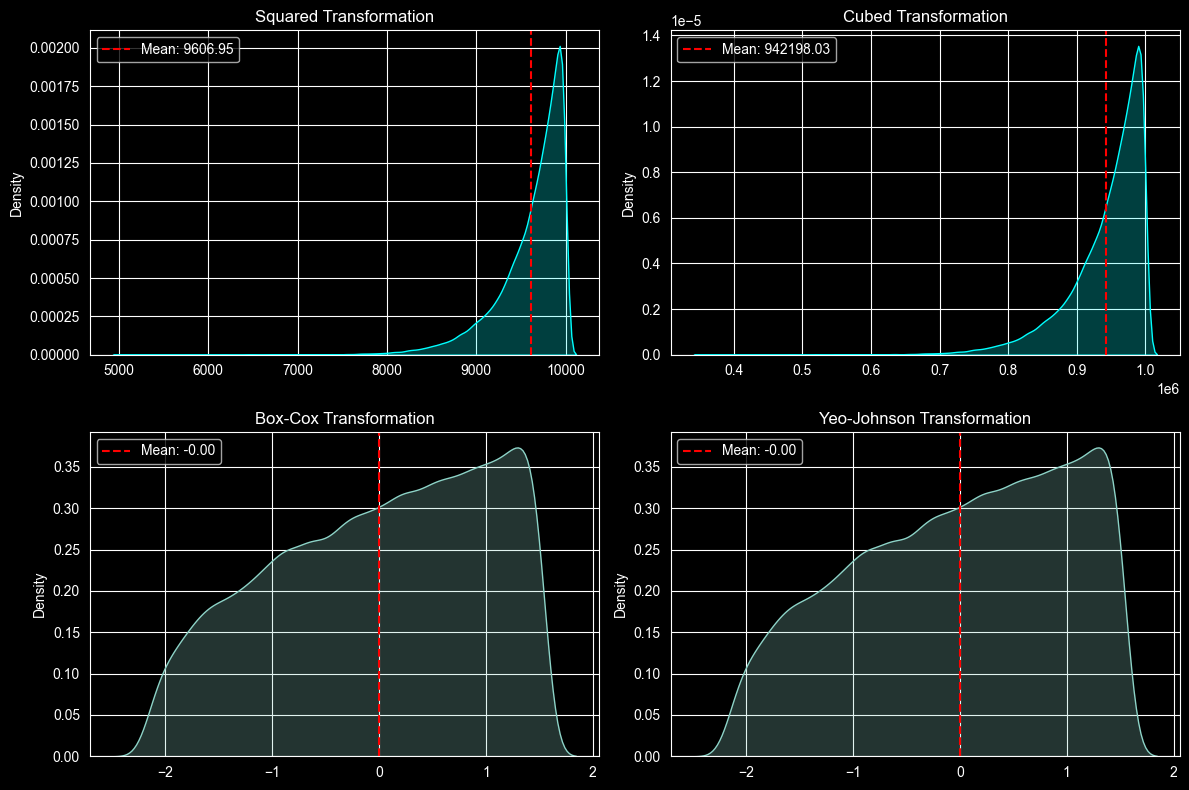

In [59]:
fig, ax = plt.subplots(2,2, figsize=(12,8))

ax = ax.flatten()

data_list = [squared_skewed_data, cubed_skewed_data, box_cox_skewed_data, yeo_johnson_skewed_data]

titles = ["Squared Transformation", "Cubed Transformation","Box-Cox Transformation", "Yeo-Johnson Transformation"]

for index, data in enumerate(data_list):

    sns.kdeplot(data, color="cyan", fill=True, ax=ax[index])

    mean_value = data.mean()

    ax[index].axvline(mean_value, color="red", linestyle="dashed", label=f"Mean: {mean_value:.2f}")

    ax[index].set_title(titles[index])

    ax[index].legend()

plt.tight_layout()
plt.show()